[23:49:01] INFO: 1. Loading & Preprocessing Data...
✓ Data loaded: 1888 rows, 51 columns
[23:49:01] INFO:    Original Rows: 1888 -> Clean Rows: 1887
PREPROCESSING (DataFrame Input)
✓ Numeric features selected: 51 columns
  Features: ['BADGE', 'TINGGI', 'BERAT', 'NADI', 'PERNAPASAN', 'SUHU', 'CONJUNGTIVA', 'HAEMORROID', 'LEHER', 'IRAMA_JANTUNG', 'TREMOR', 'PERUT', 'LIMPA', 'HB', 'LEUKOSIT', 'LED', 'EOSINOPIL', 'BASOPIL', 'SEGMENT', 'LYMPOSIT', 'MONOSIT', 'TROMBOSIT', 'PROTEIN_ALBUMIN', 'REDUKSI', 'ERITROSIT_RBC', 'LEKOSIT_WBC', 'SEL_EPITEL', 'BILIRUBIN_TOTAL', 'BILIRUBIN_DIRECT', 'BILIRUBIN_INDIRECT', 'ALKALINE_PHOSPAT', 'SGPT', 'SGOT', 'GAMMA_GT', 'KOLEST_TOTAL', 'TRIGLISERIDA', 'HDL_KOLEST', 'LDL_KOLEST', 'UREUM', 'KREATININ', 'ASAM_URAT_GINJAL', 'GULA_DARAH_PUASA', 'GULA_DARAH_2JAMPP', 'SISTOLIK', 'DIASTOLIK', 'TRIMESTER', 'ANY_EAR_ABNORMAL', 'ANY_NOSE_ABNORMAL', 'ANY_THROAT_ABNORMAL', 'ANY_MOUTH_ABNORMAL', 'BMI_CALC']
✓ No missing values found
✓ Yeo-Johnson transformation applied
  

PSO Optimization:   7%|▋         | 1/14 [00:01<00:23,  1.82s/it]

[23:49:03] INFO: Iter 1/14 - best_fitness=-0.2601


PSO Optimization:  14%|█▍        | 2/14 [00:04<00:24,  2.04s/it]

[23:49:05] INFO: Iter 2/14 - best_fitness=-0.2602


...

[23:49:26] INFO: Iter 13/14 - best_fitness=-0.2676


PSO Optimization: 100%|██████████| 14/14 [00:27<00:00,  1.96s/it]


[23:49:28] INFO: Iter 14/14 - best_fitness=-0.2676
[23:49:28] SUCCESS: PSO finished
[23:49:28] SUCCESS: PSO Finished in 27.51s
[23:49:28] INFO:    Best Parameters: {'eps': 3.157233580675793, 'min_samples': 18, 'fitness': -0.26760172320147896}
[23:49:28] INFO: 4. Running Final DBSCAN Clustering...
[23:49:28] SUCCESS:    Clusters found: 2
[23:49:28] INFO:    Noise points: 69
[23:49:28] INFO: 5. Calculating Metrics...
[23:49:28] SUCCESS:    Metrics: {'silhouette': 0.3041677009439273, 'dbi': 1.303062037406293, 'ch': 319.0909349951725}
[23:49:28] INFO: 6. Generating Visualizations...
[23:49:28] INFO:    Generating 3D Structure Plot...
✓ Saved interactive 3D plot: output/3d_clusters.html


[23:49:30] INFO:    Generating Cluster Profiles (Radar & Box)...
[INFO] Cluster profiles saved to: cluster_profiles.html (Features=51, Rows=17)


[23:49:31] INFO:    Generating Technical Report...
✓ Saved report: output/full_report.png


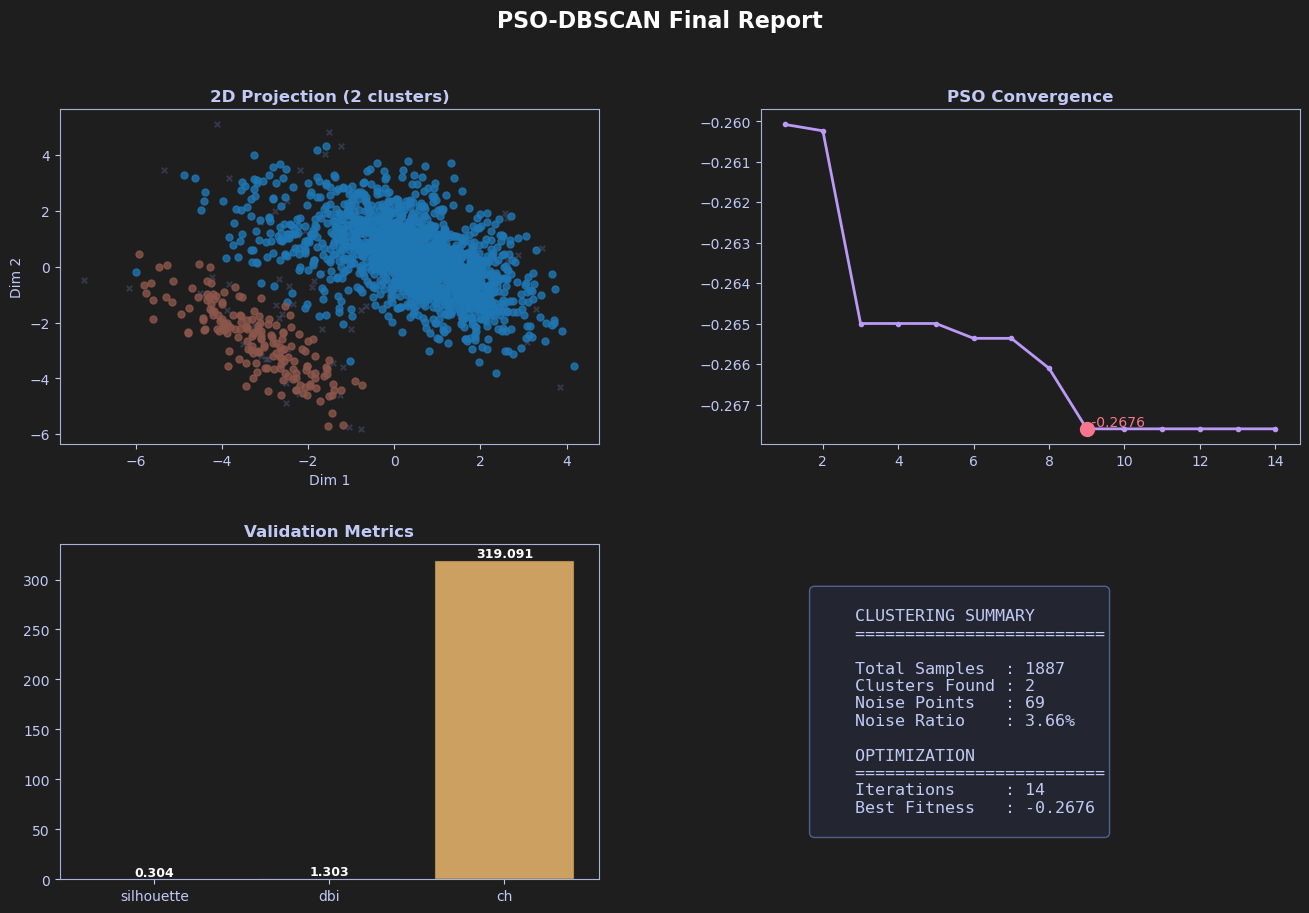

[23:49:32] SUCCESS: === ALL PROCESSES COMPLETED SUCCESSFULLY ===


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from src.aco_optimization import ACO
# Import Internal Modules
from src.preprocessing import DataPreprocessor
from src.embedding import PCAEmbedder, UMAPEmbedder
from src.optimization import PSO
from src.clustering import DBSCAN
from src.evaluation import (
    silhouette_score as sk_silhouette,
    davies_bouldin_index,
    calinski_harabasz_index
)
from src.visualization import (
    plot_clusters_3d,
    plot_full_report,
    plot_cluster_profiles  # <--- IMPORT THE NEW FUNCTION
)
from src.utils import Logger, Timer
from config import CONFIG

# 1. Setup Logging & Timer
logger = Logger(verbose=True)
timer = Timer()

try:
    # ---------------------------------------------------------
    # STEP 1: Load & Preprocess Data
    # ---------------------------------------------------------
    logger.info("1. Loading & Preprocessing Data...")
    preprocessor = DataPreprocessor()
    
    # 1. Load Data
    raw_df = preprocessor.load_data('data/Cleaned_Pasien_MCU_LastVisit.csv') 
    
    # --- PERBAIKAN PENTING ---
    # Kita harus membuang NaN di sini agar 'df' sinkron dengan hasil transform.
    # Jika preprocessor Anda melakukan dropna(), kita harus melakukannya juga di sini.
    df = raw_df.dropna().reset_index(drop=True)
    
    logger.info(f"   Original Rows: {len(raw_df)} -> Clean Rows: {len(df)}")

    # 2. Transform data yang SUDAH bersih
    X_scaled = preprocessor.transform(df)
    
    # ---------------------------------------------------------
    # STEP 2: Embedding (Switchable: PCA or UMAP)
    # ---------------------------------------------------------
    method = CONFIG['embedding'].get('method', 'pca')
    logger.info(f"2. Applying {method.upper()} Embedding...")

    if method == 'umap':
        umap_cfg = CONFIG['embedding']['umap']
        embedder = UMAPEmbedder(
            n_neighbors=umap_cfg.get('n_neighbors', 15),
            min_dist=umap_cfg.get('min_dist', 0.1),
            n_components=umap_cfg.get('n_components', 5)
        )
    else:
        # Default to PCA
        pca_cfg = CONFIG['embedding']['pca']
        embedder = PCAEmbedder(n_components=pca_cfg.get('n_components', 10))

    X_embedded = embedder.fit_transform(X_scaled)
    
    logger.info(f"   Data Shape after {method.upper()}: {X_embedded.shape}")
    
    from src.visualization import plot_objective_landscape
    fig_landscape = plot_objective_landscape(
        X=X_embedded,  # Gunakan hasil UMAP/PCA
        bounds=CONFIG['pso']['bounds'],
        objective_kwargs=CONFIG['objective'],
        resolution=5, 
        logger=logger
    )

# Tampilkan dan Simpan
    fig_landscape.show()

    # ---------------------------------------------------------
    # STEP 3: Hyperparameter Optimization (PSO)
    # ---------------------------------------------------------
    logger.info("3. Starting PSO Optimization...")
    timer.start()
    
    pso = PSO(
        **CONFIG['pso'],
        logger=logger,
        objective_kwargs=CONFIG['objective']
    )
    
    # aco_optimizer = ACO(**CONFIG['pso'], logger=logger, objective_kwargs=CONFIG['objective'])
    
    best_params = pso.optimize(X_embedded)
    # best_params = aco_optimizer.optimize(X_embedded)
    
    elapsed = timer.stop()
    logger.success(f"PSO Finished in {elapsed:.2f}s")
    logger.info(f"   Best Parameters: {best_params}")

    # ---------------------------------------------------------
    # STEP 4: Final Clustering
    # ---------------------------------------------------------
    logger.info("4. Running Final DBSCAN Clustering...")
    dbscan = DBSCAN()
    labels = dbscan.fit(
        X_embedded,
        eps=best_params['eps'],
        min_samples=best_params['min_samples']
    )
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    logger.success(f"   Clusters found: {n_clusters}")
    logger.info(f"   Noise points: {n_noise}")

    # ---------------------------------------------------------
    # STEP 5: Evaluation Metrics
    # ---------------------------------------------------------
    logger.info("5. Calculating Metrics...")
    
    if n_clusters > 1:
        mask = labels != -1
        metrics = {
            'silhouette': sk_silhouette(X_embedded[mask], labels[mask]) if mask.sum() > 2 else 0,
            'dbi': davies_bouldin_index(X_embedded, labels),
            'ch': calinski_harabasz_index(X_embedded, labels)
        }
    else:
        metrics = {'silhouette': 0, 'dbi': 0, 'ch': 0}
        
    logger.success(f"   Metrics: {metrics}")

    # ---------------------------------------------------------
    # STEP 6: Visualization & Reporting
    # ---------------------------------------------------------
    logger.info("6. Generating Visualizations...")
    
    # A. Interactive 3D Plot (Structure)
    logger.info("   Generating 3D Structure Plot...")
    pca_3d = PCA(n_components=3, random_state=42)
    X_plot_3d = pca_3d.fit_transform(X_scaled) 
    
    plot_clusters_3d(
        X_plot_3d, 
        labels, 
        title=f"3D PCA Clustering (Eps: {best_params['eps']:.2f})", 
        save_path="output/3d_clusters.html"
    )

    # B. Interactive Profile Plot (Radar & Boxplot) <-- NEW ADDITION
    logger.info("   Generating Cluster Profiles (Radar & Box)...")
    plot_cluster_profiles(
        df=df,              # Dataframe original (sudah bersih) untuk nilai metrik
        labels=labels,      # Hasil clustering dari DBSCAN

        show_plot=True      # Tampilkan plot interaktif juga
        
    )
    # C. Full Static Report (Matplotlib)
    logger.info("   Generating Technical Report...")
    plot_full_report(
        X_embedded=X_embedded, 
        labels=labels, 
        pso_history=pso.history, 
        metrics=metrics, 
        save_path= "output/full_report.png"
    )

    logger.success("=== ALL PROCESSES COMPLETED SUCCESSFULLY ===")

except Exception as e:
    logger.error(f"Pipeline Failed: {str(e)}")
    raise e

[00:07:33] INFO: 1. Loading & Preprocessing Data...
✓ Data loaded: 1888 rows, 51 columns
[00:07:33] INFO:    Original Rows: 1888 -> Clean Rows: 1887
PREPROCESSING (DataFrame Input)
✓ Numeric features selected: 51 columns
  Features: ['BADGE', 'TINGGI', 'BERAT', 'NADI', 'PERNAPASAN', 'SUHU', 'CONJUNGTIVA', 'HAEMORROID', 'LEHER', 'IRAMA_JANTUNG', 'TREMOR', 'PERUT', 'LIMPA', 'HB', 'LEUKOSIT', 'LED', 'EOSINOPIL', 'BASOPIL', 'SEGMENT', 'LYMPOSIT', 'MONOSIT', 'TROMBOSIT', 'PROTEIN_ALBUMIN', 'REDUKSI', 'ERITROSIT_RBC', 'LEKOSIT_WBC', 'SEL_EPITEL', 'BILIRUBIN_TOTAL', 'BILIRUBIN_DIRECT', 'BILIRUBIN_INDIRECT', 'ALKALINE_PHOSPAT', 'SGPT', 'SGOT', 'GAMMA_GT', 'KOLEST_TOTAL', 'TRIGLISERIDA', 'HDL_KOLEST', 'LDL_KOLEST', 'UREUM', 'KREATININ', 'ASAM_URAT_GINJAL', 'GULA_DARAH_PUASA', 'GULA_DARAH_2JAMPP', 'SISTOLIK', 'DIASTOLIK', 'TRIMESTER', 'ANY_EAR_ABNORMAL', 'ANY_NOSE_ABNORMAL', 'ANY_THROAT_ABNORMAL', 'ANY_MOUTH_ABNORMAL', 'BMI_CALC']
✓ No missing values found
✓ Yeo-Johnson transformation applied
  

[00:07:37] INFO: 3. Starting PSO Optimization...
[00:07:37] INFO: ACO Started: ants=30, iter=14


ACO Optimization:   7%|▋         | 1/14 [00:01<00:18,  1.39s/it]

[00:07:38] INFO: Iter 1/14 - Best Fit: -0.1143


ACO Optimization:  14%|█▍        | 2/14 [00:05<00:32,  2.73s/it]

...

[00:08:15] INFO: Iter 13/14 - Best Fit: -0.2688


ACO Optimization: 100%|██████████| 14/14 [00:39<00:00,  2.85s/it]


[00:08:17] INFO: Iter 14/14 - Best Fit: -0.2688
[00:08:17] SUCCESS: ACO finished
[00:08:17] SUCCESS: PSO Finished in 39.84s
[00:08:17] INFO:    Best Parameters: {'eps': 2.835812993527422, 'min_samples': 8, 'fitness': -0.2687728454534093}
[00:08:17] INFO: 4. Running Final DBSCAN Clustering...
[00:08:17] SUCCESS:    Clusters found: 3
[00:08:17] INFO:    Noise points: 109
[00:08:17] INFO: 5. Calculating Metrics...
[00:08:17] SUCCESS:    Metrics: {'silhouette': 0.2803255746531973, 'dbi': 1.3643301836220878, 'ch': 164.9068915985276}
[00:08:17] INFO: 6. Generating Visualizations...
[00:08:17] INFO:    Generating 3D Structure Plot...
✓ Saved interactive 3D plot: output/3d_clusters.html


[00:08:18] INFO:    Generating Cluster Profiles (Radar & Box)...
[INFO] Cluster profiles saved to: cluster_profiles.html (Features=51, Rows=17)


[00:08:19] INFO:    Generating Technical Report...
✓ Saved report: output/full_report.png


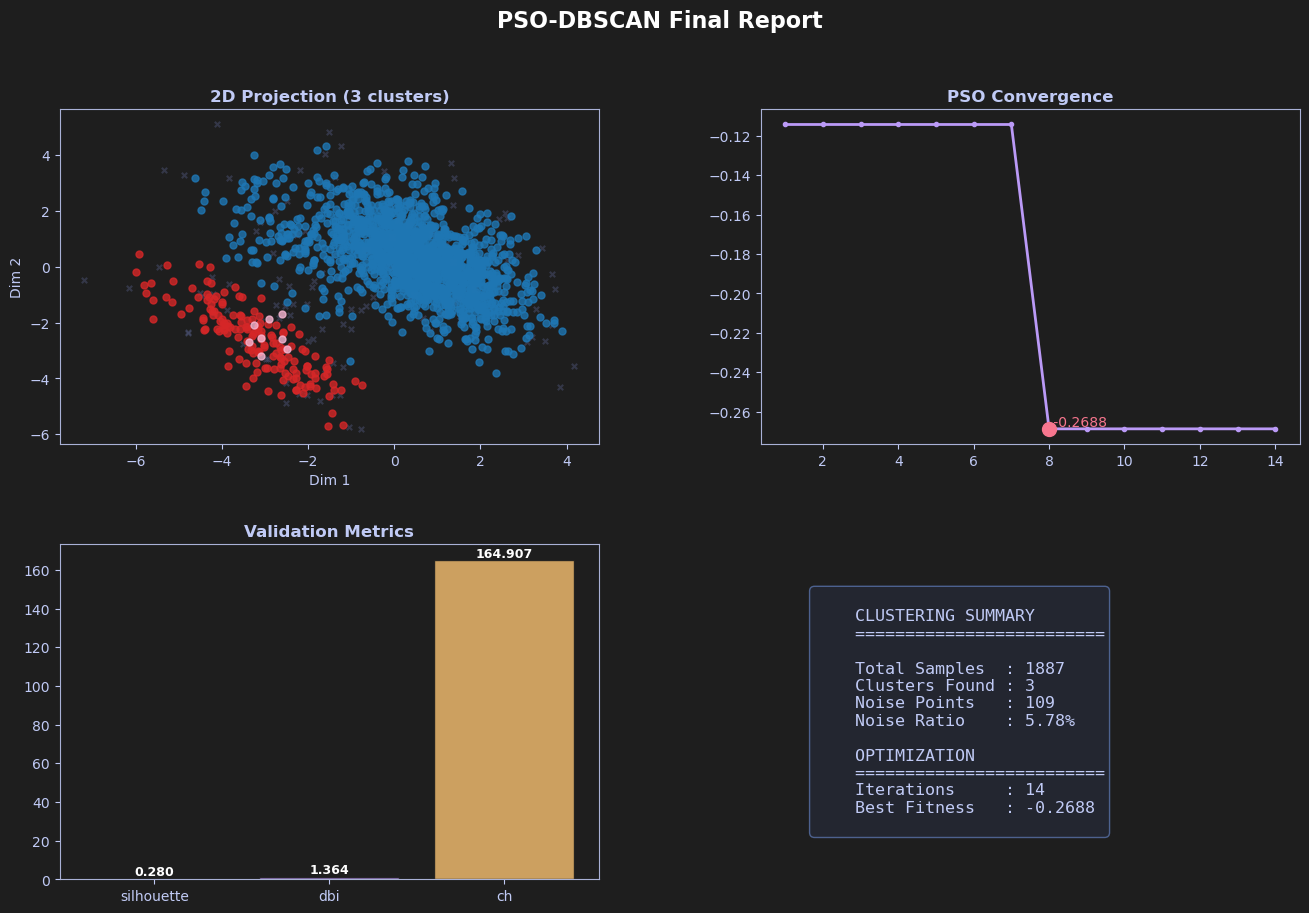

[00:08:21] SUCCESS: === ALL PROCESSES COMPLETED SUCCESSFULLY ===


In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from src.aco_optimization import ACO
# Import Internal Modules
from src.preprocessing import DataPreprocessor
from src.embedding import PCAEmbedder, UMAPEmbedder
from src.optimization import PSO
from src.clustering import DBSCAN
from src.evaluation import (
    silhouette_score as sk_silhouette,
    davies_bouldin_index,
    calinski_harabasz_index
)
from src.visualization import (
    plot_clusters_3d,
    plot_full_report,
    plot_cluster_profiles  # <--- IMPORT THE NEW FUNCTION
)
from src.utils import Logger, Timer
from config import CONFIG

# 1. Setup Logging & Timer
logger = Logger(verbose=True)
timer = Timer()

try:
    # ---------------------------------------------------------
    # STEP 1: Load & Preprocess Data
    # ---------------------------------------------------------
    logger.info("1. Loading & Preprocessing Data...")
    preprocessor = DataPreprocessor()
    
    # 1. Load Data
    raw_df = preprocessor.load_data('data/Cleaned_Pasien_MCU_LastVisit.csv') 
    
    # --- PERBAIKAN PENTING ---
    # Kita harus membuang NaN di sini agar 'df' sinkron dengan hasil transform.
    # Jika preprocessor Anda melakukan dropna(), kita harus melakukannya juga di sini.
    df = raw_df.dropna().reset_index(drop=True)
    
    logger.info(f"   Original Rows: {len(raw_df)} -> Clean Rows: {len(df)}")

    # 2. Transform data yang SUDAH bersih
    X_scaled = preprocessor.transform(df)
    
    # ---------------------------------------------------------
    # STEP 2: Embedding (Switchable: PCA or UMAP)
    # ---------------------------------------------------------
    method = CONFIG['embedding'].get('method', 'pca')
    logger.info(f"2. Applying {method.upper()} Embedding...")

    if method == 'umap':
        umap_cfg = CONFIG['embedding']['umap']
        embedder = UMAPEmbedder(
            n_neighbors=umap_cfg.get('n_neighbors', 15),
            min_dist=umap_cfg.get('min_dist', 0.1),
            n_components=umap_cfg.get('n_components', 5)
        )
    else:
        # Default to PCA
        pca_cfg = CONFIG['embedding']['pca']
        embedder = PCAEmbedder(n_components=pca_cfg.get('n_components', 10))

    X_embedded = embedder.fit_transform(X_scaled)
    
    logger.info(f"   Data Shape after {method.upper()}: {X_embedded.shape}")
    
    
    
    logger.info("Visualizing Optimization Landscape...")
    
    from src.visualization import plot_objective_landscape
    fig_landscape = plot_objective_landscape(
        X=X_embedded,  # Gunakan hasil UMAP/PCA
        bounds=CONFIG['pso']['bounds'],
        objective_kwargs=CONFIG['objective'],
        resolution=5, 
        logger=logger
    )

# Tampilkan dan Simpan
    fig_landscape.show()

    # ---------------------------------------------------------
    # STEP 3: Hyperparameter Optimization (PSO)
    # ---------------------------------------------------------
    logger.info("3. Starting PSO Optimization...")
    timer.start()
    
    # pso = PSO(
    #     **CONFIG['pso'],
    #     logger=logger,
    #     objective_kwargs=CONFIG['objective']
    # )
    
    aco_optimizer = ACO(**CONFIG['pso'], logger=logger, objective_kwargs=CONFIG['objective'])
    
    # best_params = pso.optimize(X_embedded)
    best_params = aco_optimizer.optimize(X_embedded)
    
    elapsed = timer.stop()
    logger.success(f"PSO Finished in {elapsed:.2f}s")
    logger.info(f"   Best Parameters: {best_params}")

    # ---------------------------------------------------------
    # STEP 4: Final Clustering
    # ---------------------------------------------------------
    logger.info("4. Running Final DBSCAN Clustering...")
    dbscan = DBSCAN()
    labels = dbscan.fit(
        X_embedded,
        eps=best_params['eps'],
        min_samples=best_params['min_samples']
    )
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    logger.success(f"   Clusters found: {n_clusters}")
    logger.info(f"   Noise points: {n_noise}")

    # ---------------------------------------------------------
    # STEP 5: Evaluation Metrics
    # ---------------------------------------------------------
    logger.info("5. Calculating Metrics...")
    
    if n_clusters > 1:
        mask = labels != -1
        metrics = {
            'silhouette': sk_silhouette(X_embedded[mask], labels[mask]) if mask.sum() > 2 else 0,
            'dbi': davies_bouldin_index(X_embedded, labels),
            'ch': calinski_harabasz_index(X_embedded, labels)
        }
    else:
        metrics = {'silhouette': 0, 'dbi': 0, 'ch': 0}
        
    logger.success(f"   Metrics: {metrics}")

    # ---------------------------------------------------------
    # STEP 6: Visualization & Reporting
    # ---------------------------------------------------------
    logger.info("6. Generating Visualizations...")
    
    # A. Interactive 3D Plot (Structure)
    logger.info("   Generating 3D Structure Plot...")
    pca_3d = PCA(n_components=3, random_state=42)
    X_plot_3d = pca_3d.fit_transform(X_scaled) 
    
    plot_clusters_3d(
        X_plot_3d, 
        labels, 
        title=f"3D PCA Clustering (Eps: {best_params['eps']:.2f})", 
        save_path="output/3d_clusters.html"
    )

    # B. Interactive Profile Plot (Radar & Boxplot) <-- NEW ADDITION
    logger.info("   Generating Cluster Profiles (Radar & Box)...")
    plot_cluster_profiles(
        df=df,              # Dataframe original (sudah bersih) untuk nilai metrik
        labels=labels,      # Hasil clustering dari DBSCAN
          # Riwayat optimasi ACO  
        show_plot=True      # Tampilkan plot interaktif juga
        
    )
    # C. Full Static Report (Matplotlib)
    logger.info("   Generating Technical Report...")
    plot_full_report(
        X_embedded=X_embedded, 
        labels=labels, 
        pso_history=aco_optimizer.history,
        # pso_history=pso.history, 
        metrics=metrics, 
        save_path= "output/full_report.png"
    )

    logger.success("=== ALL PROCESSES COMPLETED SUCCESSFULLY ===")

except Exception as e:
    logger.error(f"Pipeline Failed: {str(e)}")
    raise e

[00:43:17] INFO: 1. Loading & Preprocessing Data...
✓ Data loaded: 1888 rows, 51 columns
[00:43:17] INFO:    Original Rows: 1888 -> Clean Rows: 1887
PREPROCESSING (DataFrame Input)
✓ Numeric features selected: 50 columns
  Features: ['TINGGI', 'BERAT', 'NADI', 'PERNAPASAN', 'SUHU', 'CONJUNGTIVA', 'HAEMORROID', 'LEHER', 'IRAMA_JANTUNG', 'TREMOR', 'PERUT', 'LIMPA', 'HB', 'LEUKOSIT', 'LED', 'EOSINOPIL', 'BASOPIL', 'SEGMENT', 'LYMPOSIT', 'MONOSIT', 'TROMBOSIT', 'PROTEIN_ALBUMIN', 'REDUKSI', 'ERITROSIT_RBC', 'LEKOSIT_WBC', 'SEL_EPITEL', 'BILIRUBIN_TOTAL', 'BILIRUBIN_DIRECT', 'BILIRUBIN_INDIRECT', 'ALKALINE_PHOSPAT', 'SGPT', 'SGOT', 'GAMMA_GT', 'KOLEST_TOTAL', 'TRIGLISERIDA', 'HDL_KOLEST', 'LDL_KOLEST', 'UREUM', 'KREATININ', 'ASAM_URAT_GINJAL', 'GULA_DARAH_PUASA', 'GULA_DARAH_2JAMPP', 'SISTOLIK', 'DIASTOLIK', 'TRIMESTER', 'ANY_EAR_ABNORMAL', 'ANY_NOSE_ABNORMAL', 'ANY_THROAT_ABNORMAL', 'ANY_MOUTH_ABNORMAL', 'BMI_CALC']
✓ No missing values found
✓ Yeo-Johnson transformation applied
  Original 

[00:43:19] INFO: 3. Starting PSO Optimization...
[00:43:19] INFO: PSO started: particles=30, iter=14


PSO Optimization:   7%|▋         | 1/14 [00:01<00:24,  1.90s/it]

[00:43:21] INFO: Iter 1/14 - best_fitness=-0.2176


PSO Optimization:  14%|█▍        | 2/14 [00:04<00:25,  2.11s/it]

...

[00:43:48] INFO: Iter 13/14 - best_fitness=-0.2699


PSO Optimization: 100%|██████████| 14/14 [00:31<00:00,  2.22s/it]


[00:43:50] INFO: Iter 14/14 - best_fitness=-0.2699
[00:43:50] SUCCESS: PSO finished
[00:43:50] SUCCESS: PSO Finished in 31.06s
[00:43:50] INFO:    Best Parameters: {'eps': 2.853409156008783, 'min_samples': 7, 'fitness': -0.26990760967318717}
[00:43:50] INFO: 4. Running Final DBSCAN Clustering...
[00:43:50] SUCCESS:    Clusters found: 3
[00:43:50] INFO:    Noise points: 99
[00:43:50] INFO: 5. Calculating Metrics...
[00:43:50] SUCCESS:    Metrics: {'silhouette': 0.2804004554601506, 'dbi': 1.3691861263259166, 'ch': 169.23976830211174}
[00:43:50] INFO: 6. Generating Visualizations...
[00:43:50] INFO:    Generating 3D Structure Plot...
✓ Saved interactive 3D plot: output/3d_clusters.html


[00:43:51] INFO:    Generating Cluster Profiles (Radar & Box)...
[INFO] Cluster profiles saved to: cluster_profiles.html (Features=51, Rows=17)


[00:43:52] INFO:    Generating Technical Report...
✓ Saved report: output/full_report.png


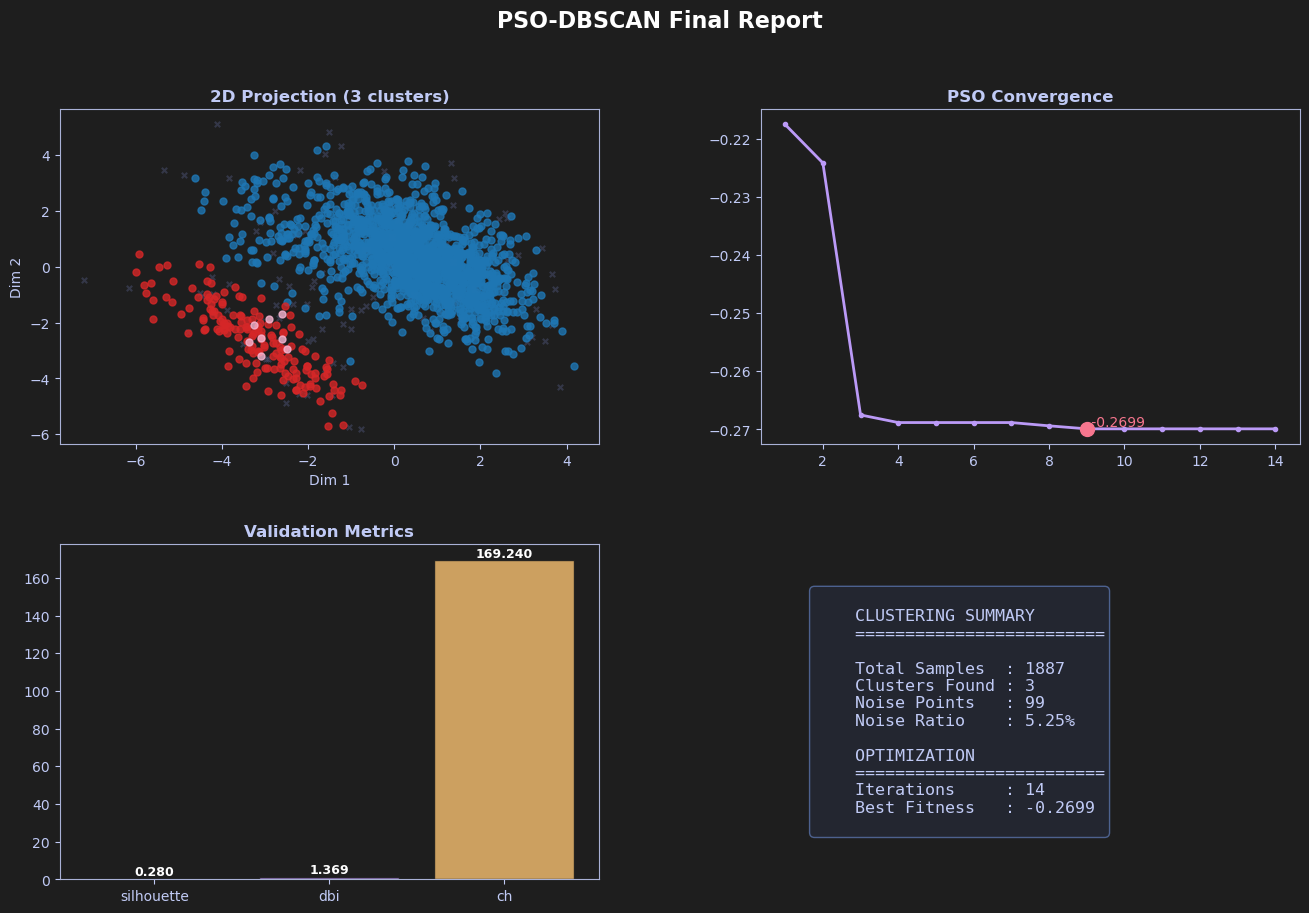

[00:43:54] SUCCESS: === ALL PROCESSES COMPLETED SUCCESSFULLY ===


In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from src.aco_optimization import ACO
# Import Internal Modules
from src.preprocessing import DataPreprocessor
from src.embedding import PCAEmbedder, UMAPEmbedder
from src.optimization import PSO
from src.clustering import DBSCAN
from src.evaluation import (
    silhouette_score as sk_silhouette,
    davies_bouldin_index,
    calinski_harabasz_index
)
from src.visualization import (
    plot_clusters_3d,
    plot_full_report,
    plot_cluster_profiles  # <--- IMPORT THE NEW FUNCTION
)
from src.utils import Logger, Timer
from config import CONFIG

# 1. Setup Logging & Timer
logger = Logger(verbose=True)
timer = Timer()

try:
    # ---------------------------------------------------------
    # STEP 1: Load & Preprocess Data
    # ---------------------------------------------------------
    logger.info("1. Loading & Preprocessing Data...")
    preprocessor = DataPreprocessor()
    
    # 1. Load Data
    raw_df = preprocessor.load_data('data/Cleaned_Pasien_MCU_LastVisit.csv') 
    
    # --- PERBAIKAN PENTING ---
    # Kita harus membuang NaN di sini agar 'df' sinkron dengan hasil transform.
    # Jika preprocessor Anda melakukan dropna(), kita harus melakukannya juga di sini.
    df = raw_df.dropna().reset_index(drop=True)
    df_pre = df.copy()
    df_pre = df_pre.drop(columns=['BADGE'])
    logger.info(f"   Original Rows: {len(raw_df)} -> Clean Rows: {len(df_pre)}")

    # 2. Transform data yang SUDAH bersih
    X_scaled = preprocessor.transform(df_pre)
    
    # ---------------------------------------------------------
    # STEP 2: Embedding (Switchable: PCA or UMAP)
    # ---------------------------------------------------------
    method = CONFIG['embedding'].get('method', 'pca')
    logger.info(f"2. Applying {method.upper()} Embedding...")

    if method == 'umap':
        umap_cfg = CONFIG['embedding']['umap']
        embedder = UMAPEmbedder(
            n_neighbors=umap_cfg.get('n_neighbors', 15),
            min_dist=umap_cfg.get('min_dist', 0.1),
            n_components=umap_cfg.get('n_components', 5)
        )
    else:
        # Default to PCA
        pca_cfg = CONFIG['embedding']['pca']
        embedder = PCAEmbedder(n_components=pca_cfg.get('n_components', 10))

    X_embedded = embedder.fit_transform(X_scaled)
    
    logger.info(f"   Data Shape after {method.upper()}: {X_embedded.shape}")
    
    from src.visualization import plot_objective_landscape
    fig_landscape = plot_objective_landscape(
        X=X_embedded,  # Gunakan hasil UMAP/PCA
        bounds=CONFIG['pso']['bounds'],
        objective_kwargs=CONFIG['objective'],
        resolution=5, 
        logger=logger
    )

# Tampilkan dan Simpan
    fig_landscape.show()

    # ---------------------------------------------------------
    # STEP 3: Hyperparameter Optimization (PSO)
    # ---------------------------------------------------------
    logger.info("3. Starting PSO Optimization...")
    timer.start()
    
    pso = PSO(
        **CONFIG['pso'],
        logger=logger,
        objective_kwargs=CONFIG['objective']
    )
    
    # aco_optimizer = ACO(**CONFIG['pso'], logger=logger, objective_kwargs=CONFIG['objective'])
    
    best_params = pso.optimize(X_embedded)
    # best_params = aco_optimizer.optimize(X_embedded)
    
    elapsed = timer.stop()
    logger.success(f"PSO Finished in {elapsed:.2f}s")
    logger.info(f"   Best Parameters: {best_params}")

    # ---------------------------------------------------------
    # STEP 4: Final Clustering
    # ---------------------------------------------------------
    logger.info("4. Running Final DBSCAN Clustering...")
    dbscan = DBSCAN()
    labels = dbscan.fit(
        X_embedded,
        eps=best_params['eps'],
        min_samples=best_params['min_samples']
    )
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    logger.success(f"   Clusters found: {n_clusters}")
    logger.info(f"   Noise points: {n_noise}")

    # ---------------------------------------------------------
    # STEP 5: Evaluation Metrics
    # ---------------------------------------------------------
    logger.info("5. Calculating Metrics...")
    
    if n_clusters > 1:
        mask = labels != -1
        metrics = {
            'silhouette': sk_silhouette(X_embedded[mask], labels[mask]) if mask.sum() > 2 else 0,
            'dbi': davies_bouldin_index(X_embedded, labels),
            'ch': calinski_harabasz_index(X_embedded, labels)
        }
    else:
        metrics = {'silhouette': 0, 'dbi': 0, 'ch': 0}
        
    logger.success(f"   Metrics: {metrics}")

    # ---------------------------------------------------------
    # STEP 6: Visualization & Reporting
    # ---------------------------------------------------------
    logger.info("6. Generating Visualizations...")
    
    # A. Interactive 3D Plot (Structure)
    logger.info("   Generating 3D Structure Plot...")
    pca_3d = PCA(n_components=3, random_state=42)
    X_plot_3d = pca_3d.fit_transform(X_scaled) 
    
    plot_clusters_3d(
        X_plot_3d, 
        labels, 
        title=f"3D PCA Clustering (Eps: {best_params['eps']:.2f})", 
        save_path="output/3d_clusters.html"
    )

    # B. Interactive Profile Plot (Radar & Boxplot) <-- NEW ADDITION
    logger.info("   Generating Cluster Profiles (Radar & Box)...")
    plot_cluster_profiles(
        df=df,              # Dataframe original (sudah bersih) untuk nilai metrik
        labels=labels,      # Hasil clustering dari DBSCAN

        show_plot=True      # Tampilkan plot interaktif juga
        
    )
    # C. Full Static Report (Matplotlib)
    logger.info("   Generating Technical Report...")
    plot_full_report(
        X_embedded=X_embedded, 
        labels=labels, 
        pso_history=pso.history, 
        metrics=metrics, 
        save_path= "output/full_report.png"
    )

    logger.success("=== ALL PROCESSES COMPLETED SUCCESSFULLY ===")

except Exception as e:
    logger.error(f"Pipeline Failed: {str(e)}")
    raise e